# Notebook 5: Adult Income Dataset (UCI)
**Fuente:** https://archive.ics.uci.edu/ml/datasets/adult

Dataset del censo de EE.UU. que contiene información socioeconómica de individuos. La tarea es predecir si una persona gana más o menos de $50,000 USD al año.

## Introducción
El **Adult Dataset** (también llamado Census Income) contiene 48,842 instancias con 14 atributos (edad, clase laboral, educación, estado civil, ocupación, relación familiar, raza, sexo, ganancias de capital, horas semanales, país natal, e ingresos). La variable objetivo (`income`) es binaria: `<=50K` o `>50K`. Es un problema clásico de **clasificación binaria**.

##  Carga del Dataset
Se descarga directamente desde el repositorio UCI.

In [2]:
import os
import pandas as pd
import numpy as np

try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    EXPORT_PATH = '/content/drive/MyDrive/datasets/adult/'
else:
    EXPORT_PATH = './adult_income_output/'

os.makedirs(EXPORT_PATH, exist_ok=True)

COLUMNS = [
    'age', 'workclass', 'fnlwgt', 'education', 'education_num',
    'marital_status', 'occupation', 'relationship', 'race', 'sex',
    'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income'
]

URL_TRAIN = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
URL_TEST  = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.test'

df_train_raw = pd.read_csv(URL_TRAIN, header=None, names=COLUMNS, na_values=' ?', skipinitialspace=True)
df_test_raw  = pd.read_csv(URL_TEST, header=None, names=COLUMNS, na_values=' ?', skipinitialspace=True, skiprows=1)

df = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
print(f'Dataset cargado: {df.shape}')
df.head()

Mounted at /content/drive
Dataset cargado: (48842, 15)


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


##  Identificación del Tipo de Problema

In [3]:
TARGET = 'income'
print(f'Variable objetivo: {TARGET}')
print(f'Valores únicos: {df[TARGET].unique()}')
print(f'Distribución:\n{df[TARGET].value_counts()}')
print('\n→ Tipo de problema: CLASIFICACIÓN BINARIA (>50K vs <=50K)')

Variable objetivo: income
Valores únicos: ['<=50K' '>50K' '<=50K.' '>50K.']
Distribución:
income
<=50K     24720
<=50K.    12435
>50K       7841
>50K.      3846
Name: count, dtype: int64

→ Tipo de problema: CLASIFICACIÓN BINARIA (>50K vs <=50K)


##  Análisis Exploratorio (EDA)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df.info()
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   fnlwgt          48842 non-null  int64 
 3   education       48842 non-null  object
 4   education_num   48842 non-null  int64 
 5   marital_status  48842 non-null  object
 6   occupation      48842 non-null  object
 7   relationship    48842 non-null  object
 8   race            48842 non-null  object
 9   sex             48842 non-null  object
 10  capital_gain    48842 non-null  int64 
 11  capital_loss    48842 non-null  int64 
 12  hours_per_week  48842 non-null  int64 
 13  native_country  48842 non-null  object
 14  income          48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [5]:
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


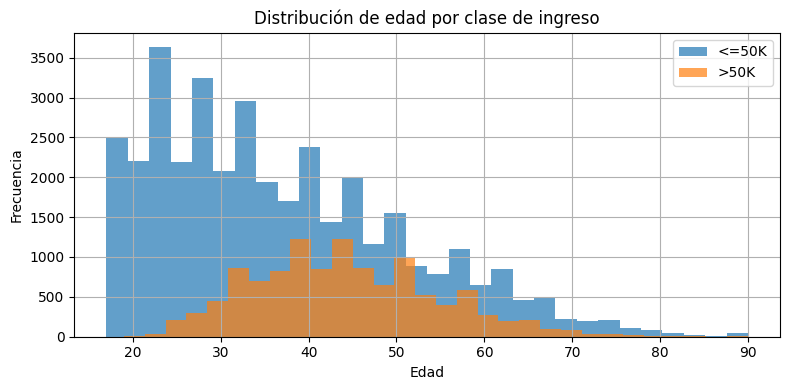

In [6]:
# Distribución de edad por clase de ingreso
df_plot = df.copy()
df_plot['income_clean'] = df_plot[TARGET].str.replace('.', '', regex=False).str.strip()
df_plot.groupby('income_clean')['age'].hist(bins=30, alpha=0.7, figsize=(8,4), legend=True)
plt.title('Distribución de edad por clase de ingreso')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

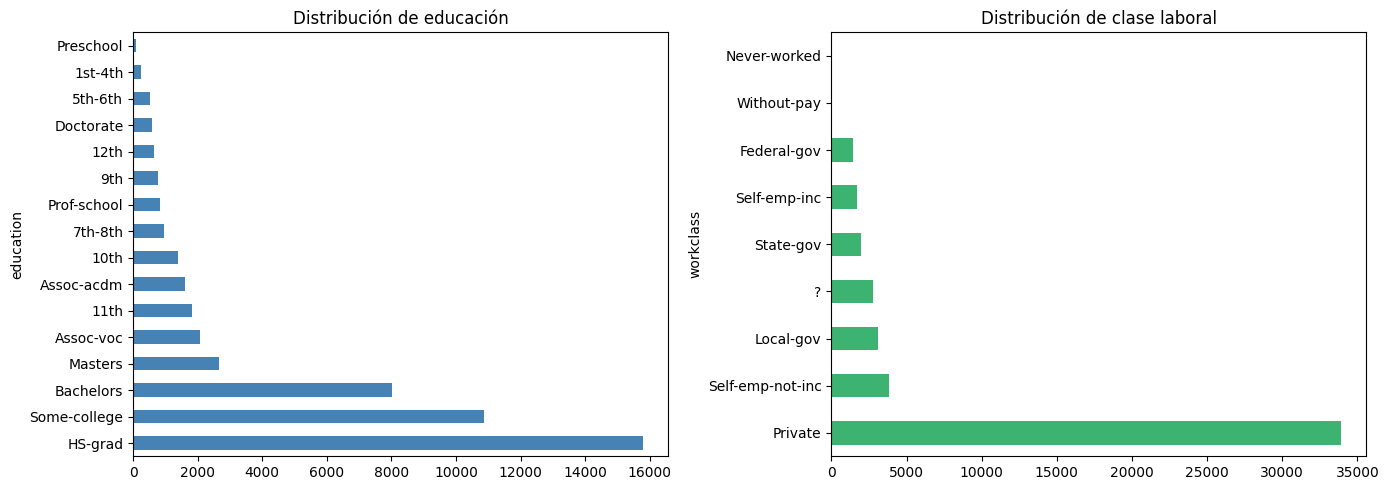

In [7]:
# Variables categóricas más relevantes
fig, axes = plt.subplots(1, 2, figsize=(14,5))
df['education'].value_counts().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución de educación')
df['workclass'].value_counts().plot(kind='barh', ax=axes[1], color='mediumseagreen')
axes[1].set_title('Distribución de clase laboral')
plt.tight_layout()
plt.show()

##  Limpieza y Preparación

In [8]:
df_clean = df.copy()

# Normalizar la columna target (eliminar punto final en datos de test)
df_clean[TARGET] = df_clean[TARGET].str.replace('.', '', regex=False).str.strip()

# Eliminar duplicados
print(f'Duplicados: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()

# Eliminar filas con nulos
before = df_clean.shape[0]
df_clean = df_clean.dropna()
print(f'Filas eliminadas por nulos: {before - df_clean.shape[0]}')

# Eliminar columna fnlwgt (peso muestral, no es feature predictivo)
df_clean = df_clean.drop(columns=['fnlwgt'], errors='ignore')

print(f'Shape final: {df_clean.shape}')

Duplicados: 52
Filas eliminadas por nulos: 0
Shape final: (48790, 14)


## Transformación y Preprocesamiento

In [9]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_processed = df_clean.copy()

# Codificar target a binario
df_processed[TARGET] = (df_processed[TARGET] == '>50K').astype(int)
print(f'Distribución target codificado:\n{df_processed[TARGET].value_counts()}')

cat_cols = df_processed.select_dtypes(include=['object']).columns.tolist()
num_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != TARGET]

le = LabelEncoder()
for col in cat_cols:
    df_processed[col] = le.fit_transform(df_processed[col].astype(str))

scaler = StandardScaler()
df_processed[num_cols] = scaler.fit_transform(df_processed[num_cols])

print(f'Shape preprocesado: {df_processed.shape}')
df_processed.head()

Distribución target codificado:
income
0    37109
1    11681
Name: count, dtype: int64
Shape preprocesado: (48790, 14)


,age,workclass,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.025328,7,9,1.136642,4,1,1,4,1,0.146702,-0.217248,-0.034366,39,0
1,0.827758,6,9,1.136642,2,4,0,4,1,-0.144882,-0.217248,-2.213085,39,0
2,-0.047620,4,11,-0.419766,0,6,1,4,1,-0.144882,-0.217248,-0.034366,39,0
3,1.046603,4,1,-1.197970,2,6,0,2,1,-0.144882,-0.217248,-0.034366,39,0
4,-0.777103,4,9,1.136642,2,10,5,2,0,-0.144882,-0.217248,-0.034366,5,0


##  División Train/Test (80/20, stratify)

In [10]:
from sklearn.model_selection import train_test_split

X = df_processed.drop(columns=[TARGET])
y = df_processed[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

train_df = X_train.copy(); train_df[TARGET] = y_train.values
test_df  = X_test.copy();  test_df[TARGET]  = y_test.values

print(f'Train: {train_df.shape}  |  Test: {test_df.shape}')
print(f'Proporción >50K - Train: {y_train.mean():.3f}  |  Test: {y_test.mean():.3f}')

Train: (39032, 14)  |  Test: (9758, 14)
Proporción >50K - Train: 0.239  |  Test: 0.239


## Exportación de train.csv y test.csv

In [11]:
train_df.to_csv(os.path.join(EXPORT_PATH, 'train.csv'), index=False)
test_df.to_csv(os.path.join(EXPORT_PATH, 'test.csv'), index=False)
print(f'✅ train.csv guardado: {train_df.shape}')
print(f'✅ test.csv  guardado: {test_df.shape}')

✅ train.csv guardado: (39032, 14)
✅ test.csv  guardado: (9758, 14)
